In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

In [ ]:
data = pd.read_csv("/content/50StartupProfit.csv")
print(data)

     Region  Profit  R&D Spend  Administration  Marketing Spend
0   Region3  192262     165350          136898           471785
1   Region1  191793     162598          151378           443899
2   Region2  191051     153442          101146           407935
3   Region3  182902     144373          118672           383200
4   Region2  166188     142108           91392           366169
5   Region3  156992     131877           99815           362862
6   Region1  156123     134616          147199           127717
7   Region2  155753     130299          145531           323877
8   Region3  152212     120543          148719           311614
9   Region1  149760     123335          108680           304982
10  Region2  146122     101914          110595           229161
11  Region1  144260     100672           91791           249745
12  Region2  141586      93864          127321           249840
13  Region1  134308      91993          135496           252665
14  Region2  132603     119944          

In [ ]:
X = data.drop('Profit', axis=1)
y = data['Profit']

In [ ]:
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), ['Region'])
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = regressor.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison)

    Actual      Predicted
13  134308  126363.506559
39   81006   84609.166440
30   99938   99677.872201
45   64927   46358.212101
17  125371  128751.212982
48   35674   50913.470094
26  105734  109741.395391
25  107405  100643.645240
32   97428   97599.620615
19  122777  113097.653745


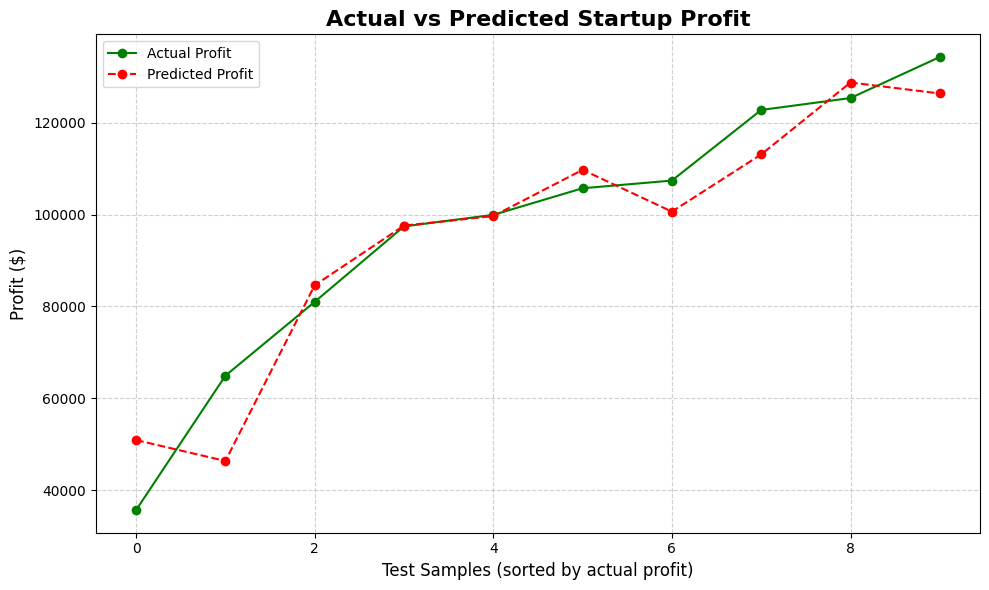

In [ ]:
sorted_indices = np.argsort(y_test)
y_test_sorted = np.array(y_test)[sorted_indices]
y_pred_sorted = np.array(y_pred)[sorted_indices]

plt.figure(figsize=(10,6))

plt.plot(y_test_sorted, color='green', marker='o', label='Actual Profit')

plt.plot(y_pred_sorted, color='red', linestyle='--', marker='o', label='Predicted Profit')

plt.title("Actual vs Predicted Startup Profit", fontsize=16, weight='bold')
plt.xlabel("Test Samples (sorted by actual profit)", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

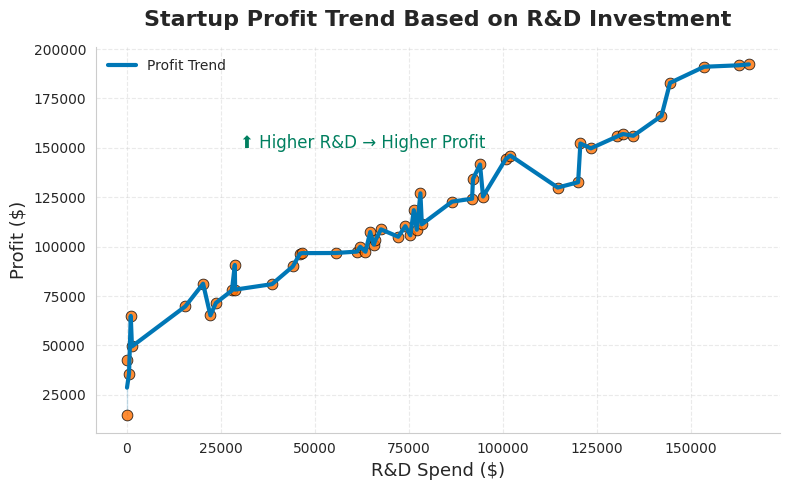

In [ ]:
import seaborn as sns

data = pd.read_csv("50StartupProfit.csv")

data = data.sort_values(by="R&D Spend")

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(
    data=data,
    x="R&D Spend",
    y="Profit",
    color="#0077b6",
    linewidth=3,
    label="Profit Trend"
)

sns.scatterplot(
    data=data,
    x="R&D Spend",
    y="Profit",
    color="#ff6f00",
    s=60,
    alpha=0.8,
    edgecolor="black"
)

plt.title("Startup Profit Trend Based on R&D Investment", fontsize=16, weight='bold', pad=15)
plt.xlabel("R&D Spend ($)", fontsize=13)
plt.ylabel("Profit ($)", fontsize=13)

plt.text(30000, 150000, "⬆ Higher R&D → Higher Profit", fontsize=12, color="#007f5f")

plt.grid(True, linestyle='--', alpha=0.4)
sns.despine()
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8987234142405655
